## _Neural Data Science Project SoSe2026_ — Parameter inference with Jaxley

**Lecturer**: Prof. Dr. Philipp Berens, Dr. Jan Lause  
**Tutors**: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler  
**Student names**: Lucía Grande González, Andre Potthoff, Niclas Collmer  
**LLM Disclaimer**: Claude (Anthropic) was used to assist with code structure, debug JAX/Jaxley API usage, and refine summary statistics. All modelling decisions and scientific interpretation are our own.

## Context

The pyloric network of the stomatogastric ganglion (STG) is a well-studied component of the crustacean nervous system. It produces a rhythmic tri-phasic motor pattern (AB/PD → LP → PY) driven by a combination of intrinsic membrane currents and mutual inhibitory synapses.

We work with a **simplified 3-neuron model** (AB/PD merged, single LP, single PY) implemented in [Jaxley](https://jaxley.readthedocs.io/). The model has 7 synaptic connections:

| Edge | Pre | Post | Type |
|------|-----|------|------|
| 0 | AB/PD | LP | Glutamatergic |
| 1 | AB/PD | LP | Cholinergic |
| 2 | AB/PD | PY | Glutamatergic |
| 3 | AB/PD | PY | Cholinergic |
| 4 | LP | AB/PD | Glutamatergic |
| 5 | LP | PY | Glutamatergic |
| 6 | PY | LP | Glutamatergic |


papers with more context:
[Similar network activity from disparate circuit parameters](https://www.nature.com/articles/nn1352); [Alternative to hand-tuning conductance-based models](https://journals.physiology.org/doi/full/10.1152/jn.00641.2003); [Training deep neural density estimators to identify mechanistic models of neural dynamics](https://elifesciences.org/articles/56261)

#### The Model
<img src="network.png" alt="image-2.png" width="800"/>

### Research question
> **What synaptic conductances gave rise to the recorded trace, and is there more than one viable parameter set?**

## 1  Setup

In [1]:
from jax import config

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".8"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
import jupyter_black

import jaxley as jx
import jax
import jax.numpy as jnp
from jaxley_models import PyloricNetwork

from scipy.optimize import differential_evolution

from utils import *

matplotlib.rcParams["figure.dpi"] = 100
print("JAX version:", jax.__version__)
print("Jaxley version:", jx.__version__)

jupyter_black.load()  # for cell formatting in jupyter notebooks

JAX version: 0.10.2
Jaxley version: 0.13.0


## 2  Data loading & exploratory analysis

In [2]:
t_obs, *v_obs_list = np.loadtxt("../data/pyloric_observation.csv", unpack=True)
v_obs = np.array(v_obs_list)  # shape (3, T)
dt_obs = float(t_obs[1] - t_obs[0])
T_obs = float(t_obs[-1])

print(f"Observation: {v_obs.shape[1]} timesteps, dt={dt_obs:.3f} ms, T={T_obs:.0f} ms")
print(f"V range:     [{v_obs.min():.1f}, {v_obs.max():.1f}] mV")

Observation: 16000 timesteps, dt=0.250 ms, T=4000 ms
V range:     [-96.5, 63.2] mV


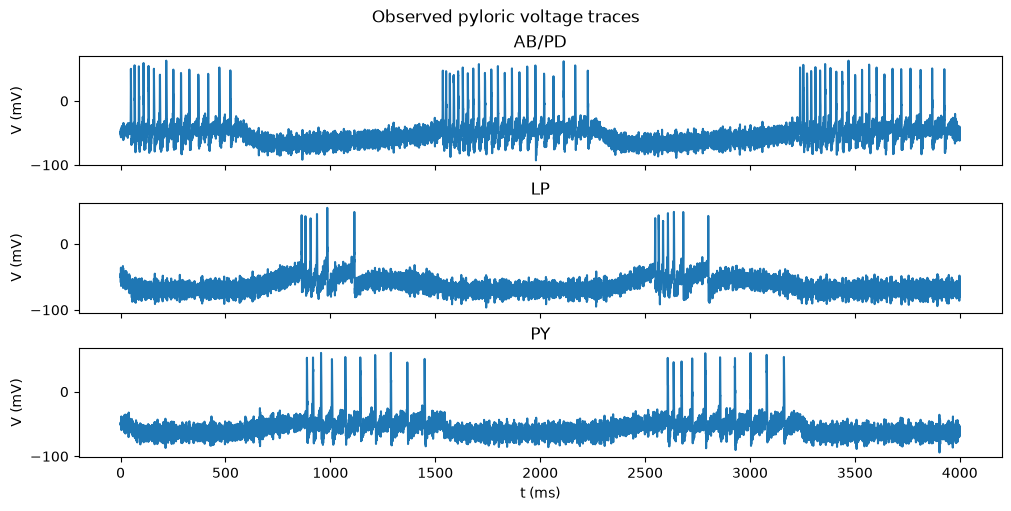

In [3]:
fig, axs = plot_pyloric(t_obs, v_obs)
fig.suptitle("Observed pyloric voltage traces", fontsize=12)
plt.show()

**Observations from the raw data:**
- Three neurons show rhythmic bursting with a period of roughly 1 – 2 s.
- AB/PD bursts first, followed ~half-period later by LP and PY (anti-phasic).
- Voltage swings between ≈ –96 mV (deep hyperpolarisation) and ≈ +63 mV (spikes), consistent with a GCaMP-free, direct patch-clamp style voltage recording.

In [4]:
# Summary statistics of the observation
stats_obs = summary_statistics(v_obs, dt=dt_obs, burn_in_ms=500.0)
print("Observation summary statistics:")
print_stats(stats_obs, label="obs")
print()
print("These are the targets we need to reproduce.")

Observation summary statistics:
  [obs] period (ms): 1666.583
  [obs] AB/PD duty cycle: 0.387
  [obs] LP duty cycle: 0.150
  [obs] PY duty cycle: 0.324
  [obs] LP phase: 0.573
  [obs] PY phase: 0.599
  [obs] AB/PD spikes/burst: 22.000
  [obs] LP spikes/burst: 6.500
  [obs] PY spikes/burst: 10.000

These are the targets we need to reproduce.


## 3  Model familiarisation

We first inspect the PyloricNetwork structure and confirm a single forward simulation works, then measure the compute cost of the full 4 s run.

In [5]:
net_demo = PyloricNetwork()
print("Nodes (neurons):")
node_cols = ["global_cell_index", "ab_pd", "lp", "py", "v", "Na_gNa", "capacitance"]
print(
    net_demo.nodes[
        [c for c in node_cols if c in net_demo.nodes.columns]
    ].drop_duplicates()
)
print()
print("Edges (synapses):")
edge_cols = [
    "global_edge_index",
    "pre_index",
    "post_index",
    "type",
    "GlutamatergicSynapse_gS",
    "CholinergicSynapse_gS",
]
print(net_demo.edges[[c for c in edge_cols if c in net_demo.edges.columns]])

Nodes (neurons):
   global_cell_index  ab_pd     lp     py     v  Na_gNa  capacitance
0                  0   True  False  False -50.0     0.3     0.999523
1                  1  False   True  False -50.0     0.1     0.999523
2                  2  False  False   True -50.0     0.5     0.999523

Edges (synapses):
   global_edge_index  pre_index  post_index                  type  \
0                  0          0           1  GlutamatergicSynapse   
1                  1          0           1    CholinergicSynapse   
2                  2          0           2  GlutamatergicSynapse   
3                  3          0           2    CholinergicSynapse   
4                  4          1           0  GlutamatergicSynapse   
5                  5          1           2  GlutamatergicSynapse   
6                  6          2           1  GlutamatergicSynapse   

   GlutamatergicSynapse_gS  CholinergicSynapse_gS  
0                   0.0001                    NaN  
1                      NaN     

### 3.1. Visualization of the Pyloric network

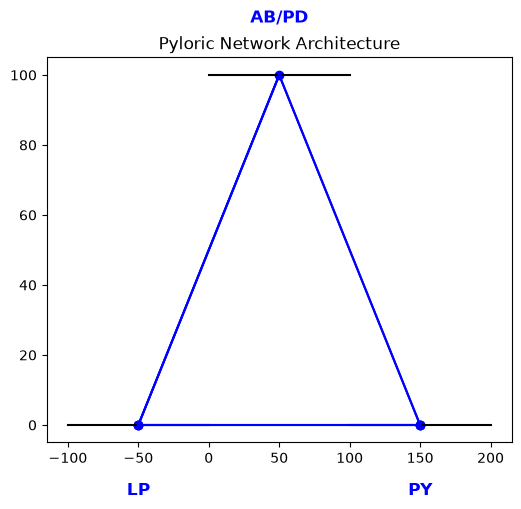

In [6]:
# 1. Initialize the internal 3D coordinates
net_demo.compute_xyz()

# 2. Move cells manually to an exact triangle shape using the integer indices from the table above
net_demo.cell(0).move_to(x=0, y=100, z=0)  # 0 = AB/PD
net_demo.cell(1).move_to(x=-100, y=0, z=0)  # 1 = LP
net_demo.cell(2).move_to(x=100, y=0, z=0)  # 2 = PY

# 3. Visualize the network
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
_ = net_demo.vis(ax=ax, detail="full", color="k")

# 4. Add the text labels near those coordinates
# 'ha' centers the text horizontally. We offset the 'y' coordinate slightly
# so the text floats just above or below the neuron.
ax.text(50, 115, "AB/PD", fontsize=12, fontweight="bold", ha="center", color="blue")
ax.text(-50, -20, "LP", fontsize=12, fontweight="bold", ha="center", color="blue")
ax.text(150, -20, "PY", fontsize=12, fontweight="bold", ha="center", color="blue")

# 5. Clean up the plot and show
plt.title("Pyloric Network Architecture")
plt.show()

### 3.3. Forward simulation

Next, we run the simulator once end-to-end and reproduce a plot comparable to the observation from default parameters given by Prinz et al., (2003)

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


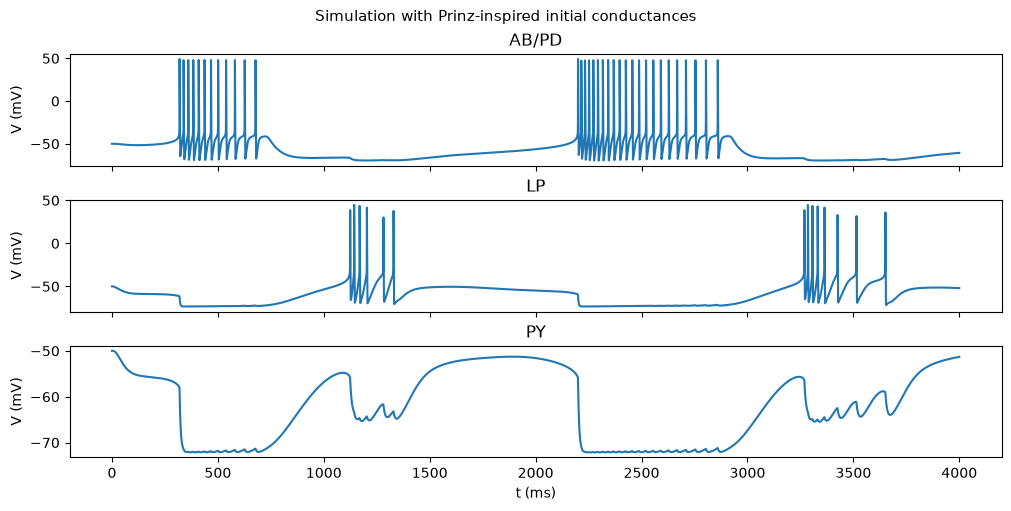

AB/PD: period=1881 ms, duty=0.27, n_bursts=2
LP: period=2144 ms, duty=0.14, n_bursts=2
PY: period=nan ms, duty=nan, n_bursts=0


In [7]:
# Default model trace (very weak synapses → near-intrinsic dynamics)

_, v_default = simulate(PRINZ_G_INIT_US, t_max=4000.0)


t_plot = np.arange(v_default.shape[1]) * 0.025
fig, axs = plot_pyloric(t_plot, v_default)
fig.suptitle("Simulation with Prinz-inspired initial conductances", fontsize=11)
plt.show()

for i, name in enumerate(["AB/PD", "LP", "PY"]):
    s = burst_stats_single(v_default[i], dt=0.025)
    print(
        f'{name}: period={s["period_ms"]:.0f} ms, duty={s["duty_cycle"]:.2f}, n_bursts={s["n_bursts"]}'
    )

## 4  Preprocessing & summary statistics

We compress the 4 s voltage trace into 9 scalar features:

| # | Statistic | Why it matters |
|---|-----------|----------------|
| 0 | Burst period (ms) | Network rhythm / primary pacemaker frequency |
| 1 | AB/PD duty cycle | Pacemaker active burst proportion |
| 2 | LP duty cycle | Second-phase active burst proportion |
| 3 | PY duty cycle | Third-phase active burst proportion |
| 4 | LP phase offset (relative to AB/PD) | Triphasic coordination / firing sequence |
| 5 | PY phase offset (relative to AB/PD) | Triphasic coordination / firing sequence |
| 6 | AB/PD spikes per burst | Pacemaker intra-burst firing intensity |
| 7 | LP spikes per burst | LP intra-burst firing intensity |
| 8 | PY spikes per burst | PY intra-burst firing intensity |

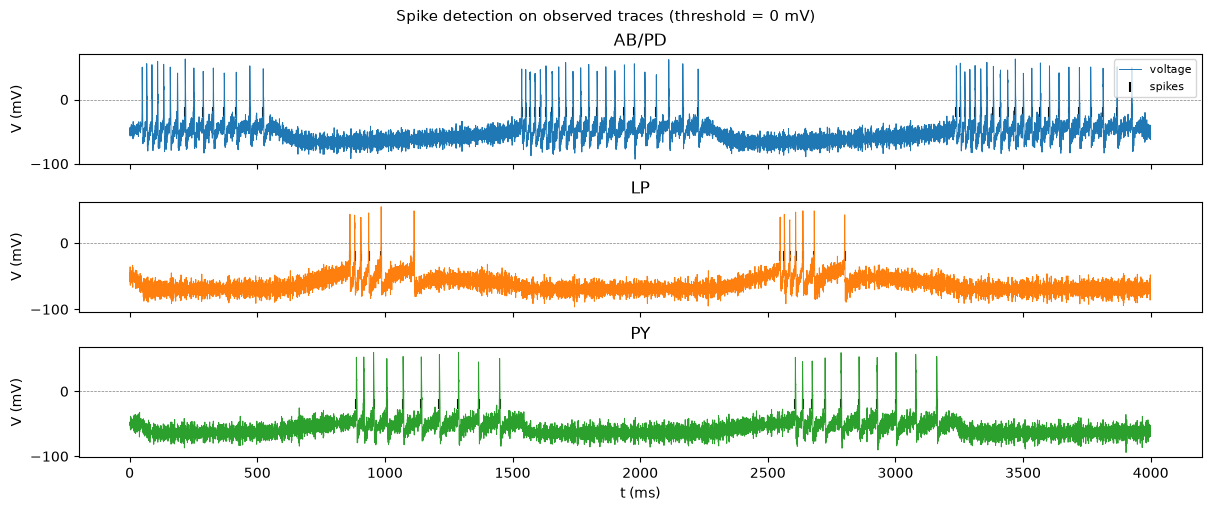

In [8]:
# Show spike & burst detection on the observation
fig, axs = plt.subplots(3, 1, figsize=(12, 5), sharex=True, layout="constrained")
neuron_names = ["AB/PD", "LP", "PY"]
colors = ["C0", "C1", "C2"]

for i, (name, col) in enumerate(zip(neuron_names, colors)):
    axs[i].plot(t_obs, v_obs[i], color=col, lw=0.7, label="voltage")
    spk = detect_spikes(v_obs[i], dt=dt_obs, threshold=0.0)
    spk = spk[spk > 200]
    axs[i].scatter(
        spk, np.full_like(spk, -20.0), marker="|", s=50, color="k", label="spikes"
    )
    axs[i].set_ylabel("V (mV)")
    axs[i].set_title(name)
    axs[i].axhline(0, color="gray", lw=0.5, ls="--")

axs[-1].set_xlabel("t (ms)")
axs[0].legend(fontsize=8)
fig.suptitle("Spike detection on observed traces (threshold = 0 mV)", fontsize=11)
plt.show()

In [9]:
# Verify summary statistics on the observation
TARGET_STATS = summary_statistics(v_obs, dt=dt_obs)
stats_obs_df = pd.DataFrame({"Statistic": STAT_LABELS, "Value": TARGET_STATS})
print(stats_obs_df.to_string(index=False))

         Statistic       Value
       period (ms) 1666.583333
  AB/PD duty cycle    0.387260
     LP duty cycle    0.149607
     PY duty cycle    0.324175
          LP phase    0.572504
          PY phase    0.599153
AB/PD spikes/burst   22.000000
   LP spikes/burst    6.500000
   PY spikes/burst   10.000000


## 5  Differential evolution optimisation
**Loss**: Weighted fractional error comparing 9 discrete biological features (network period, duty cycles, phase offsets, and spikes per burst) to the observation. Silent or non-bursting neurons yield `NaN` values, which are intercepted and assigned a scalar penalty

**Optimization Strategy**: Differential Evolution (Derivative-Free Optimization). Replaces gradient descent because the step functions inherent to spike detection are non-differentiable.

**Parameterisation**: $\log_{10}(\bar{g}) \in [-5, 1]$. Log-space ensures efficient evolutionary mutation and scaling across the 6-decade conductance range.

**Caveats**: Population-based evolutionary algorithms are massively compute-intensive. To make optimization tractable, the 4000 ms forward integration is strictly JIT-compiled via JAX (XLA) and isolated from the dynamic NumPy feature extraction.

# Below cells runs for 2 hours!

In [16]:
# 0. Restore network initialization
net_grad, param_keys_grad = build_network_for_grad()
T_MAX = 4000.0  # ms for full simulations


def compute_weighted_feature_distance(
    sim_stats: np.ndarray, target_stats: np.ndarray
) -> float:
    """
    Computes a normalized, weighted scalar distance between simulated and target features.

    Architecture:
    1. Normalization: Uses fractional error ((sim - obs) / obs) so that period (ms)
       and duty cycle (0-1) contribute equally to the loss.
    2. Missing Data Culling: Assigns a severe fixed penalty to NaN features to instantly
       kill silent or non-bursting network topologies in the evolutionary population.
    """
    # 1. Base Weights
    # In (STG) models, you often weight phase offsets (idx 4,5) higher than spike counts
    weights = np.array([1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 1.0, 1.0, 1.0])

    # 2. NaN Penalty
    nan_penalty = 10.0

    # Identify which features were successfully extracted
    valid_mask = ~np.isnan(sim_stats)

    # 3. Fractional Error Calculation
    fractional_error = np.zeros_like(sim_stats)

    # Only divide valid numbers to avoid Numpy ZeroDivision/NaN runtime warnings
    fractional_error[valid_mask] = (
        sim_stats[valid_mask] - target_stats[valid_mask]
    ) / target_stats[valid_mask]

    # 4. Apply Weights and Compute L2 Norm (Squared Error)
    squared_errors = weights * (fractional_error**2)

    # 5. Route Valid Errors and Penalties
    feature_costs = np.where(valid_mask, squared_errors, nan_penalty)

    return float(np.sum(feature_costs))


# 1. Isolate and JIT the expensive integration
@jax.jit
def simulate_fast(log10_g_flat):
    params = make_params_from_log10g(param_keys_grad, log10_g_flat)
    return jx.integrate(
        net_grad,
        params=params,
        t_max=T_MAX,  # 4000.0 ms
        delta_t=0.025,
    )


history_params = []
history_loss = []


# 2. The Loss Function (Standard Python/NumPy)
def feature_loss_fn(log10_g_flat):
    # Execute the blazing fast compiled XLA simulation
    v_sim_jax = simulate_fast(log10_g_flat)

    # Cast back to standard NumPy for dynamic feature extraction
    v_sim_np = np.array(v_sim_jax)

    # Extract discrete features
    sim_stats = summary_statistics(v_sim_np, dt=0.025, burn_in_ms=500.0)

    # Compute cost
    cost = compute_weighted_feature_distance(sim_stats, TARGET_STATS)

    # 4. Record the geometry of this evaluation
    history_params.append(log10_g_flat.copy())
    history_loss.append(cost)

    return cost


# 3. Optimization Setup
n_params = len(PRINZ_G_INIT_US)
bounds = [(-5.0, 1.0) for _ in range(n_params)]

print("=== Starting Differential Evolution Optimization ===")

# The very first evaluation will take ~5-10 seconds to compile XLA.
# Every subsequent evaluation will take milliseconds.
result = differential_evolution(
    feature_loss_fn,
    bounds,
    maxiter=50,
    popsize=5,
    disp=True,
    workers=1,  # STRICTLY 1 to avoid XLA deadlocks
)

print(f"  Final Feature Loss: {result.fun:.4f}")
print(f'  g_opt (µS): {[f"{x:.4f}" for x in 10**result.x]}')

# save all important objects
np.savez_compressed(
    "optimization_results.npz",
    params=np.array(history_params),
    losses=np.array(history_loss),
    param_names=np.array(
        param_keys_grad
    ),  # Ensures the names stay synced with the axes
)

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
=== Starting Differential Evolution Optimization ===
differential_evolution step 1: f(x)= 1.5035893880651474
differential_evolution step 2: f(x)= 0.386284647999403
differential_evolution step 3: f(x)= 0.025454171495654966
differential_evolution step 4: f(x)= 0.025454171495654966
differential_evolution step 5: f(x)= 0.025454171495654966
di

### examine the results and result landscape

In [ ]:
result
# message: Maximum number of iterations has been exceeded.
#              success: False
#                  fun: 0.0072961660086240335
#                    x: [ 2.550e-01 -1.768e+00 -1.281e+00 -2.166e+00
#                        -3.136e+00 -4.717e+00 -3.367e+00]
#                  nit: 50
#                 nfev: 1793
#           population: [[ 2.550e-01 -1.768e+00 ... -4.717e+00 -3.367e+00]
#                        [ 1.691e-01 -1.604e+00 ... -4.300e+00 -4.072e+00]
#                        ...
#                        [ 1.672e-01 -1.852e+00 ... -4.634e+00 -3.468e+00]
#                        [ 9.010e-02 -1.663e+00 ... -3.151e+00 -3.835e+00]]
#  population_energies: [ 7.296e-03  1.241e-02 ...  1.086e-02  1.002e-02]
best_parameter_set = [ 0.25495598, -1.76788206, -1.28085388, -2.16560886, -3.13587851, -4.7167629 , -3.36670664]
result.x

array([ 0.25495598, -1.76788206, -1.28085388, -2.16560886, -3.13587851,
       -4.7167629 , -3.36670664])

Loaded 1793 evaluated points.


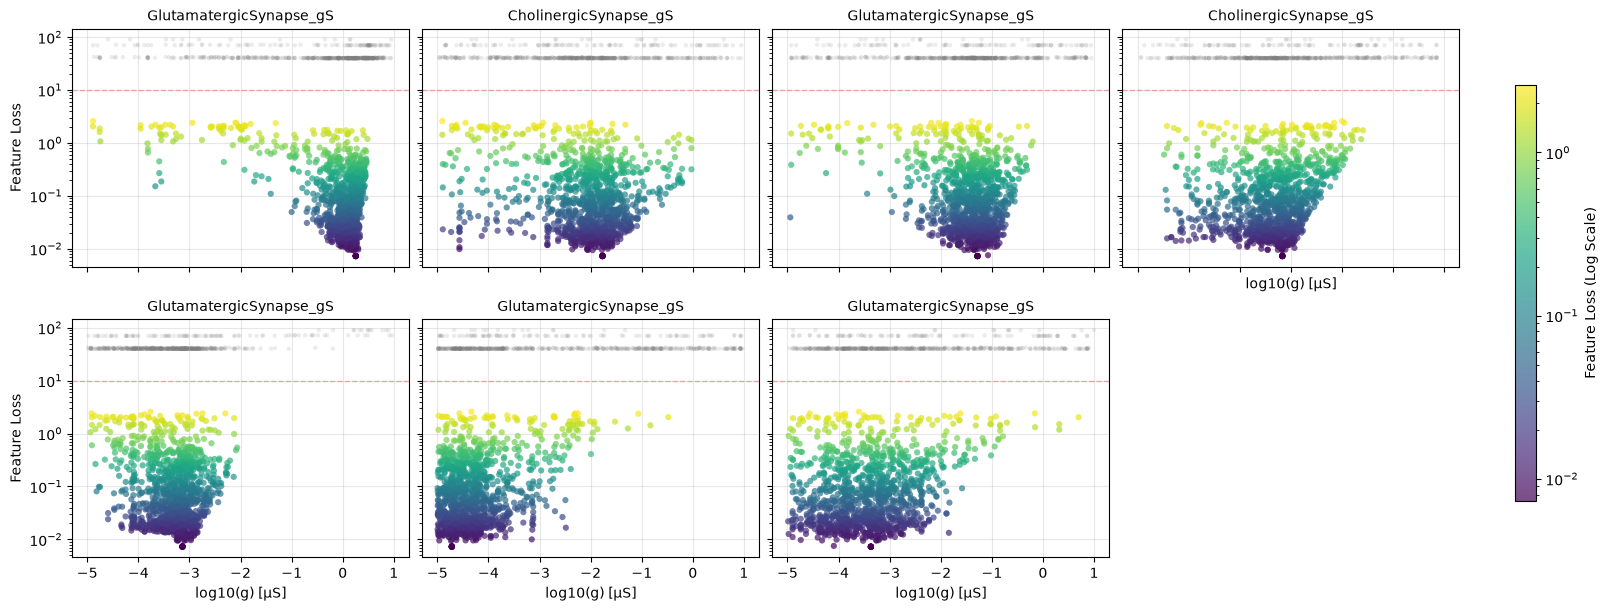

In [ ]:
# Load the compressed archive
data = np.load("optimization_results.npz")

# Extract the arrays
loaded_params = data["params"]
loaded_losses = data["losses"]
loaded_names = data["param_names"]

print(f"Loaded {len(loaded_losses)} evaluated points.")

# Draw the landscape
plot_loss_landscape(loaded_params, loaded_losses, loaded_names)

### plot the voltage traces

In [ ]:
_, v = simulate(10**result.x, t_max=4000.0)

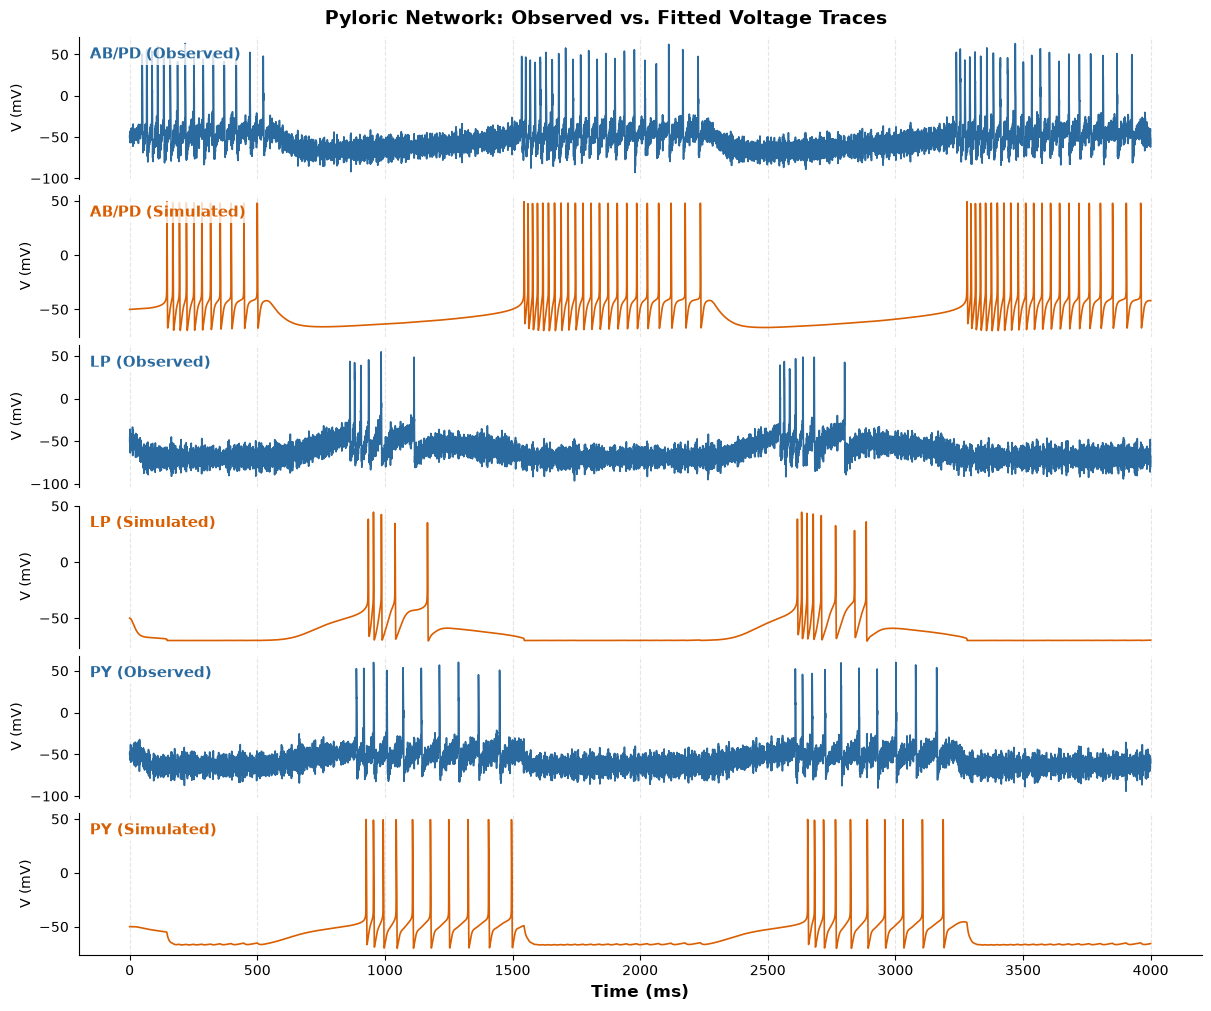

In [ ]:
# Create 6 rows, pairing observed and simulated for each cell type
fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True, layout="constrained")

cell_names = ["AB/PD", "LP", "PY"]
colors = {"obs": "#2b6a9e", "sim": "#d95f02"}  # Muted blue and distinct burnt orange

for i, name in enumerate(cell_names):
    ax_obs = axs[i * 2]  # Even rows: 0, 2, 4
    ax_sim = axs[i * 2 + 1]  # Odd rows:  1, 3, 5

    # --- 1. Plot Observed ---
    ax_obs.plot(t_obs, v_obs[i], color=colors["obs"], lw=1.2)
    ax_obs.set_ylabel("V (mV)", fontsize=10)

    # Clean up axes: remove top/right spines and bottom spine for inner plots
    ax_obs.spines[["top", "right", "bottom"]].set_visible(False)
    ax_obs.tick_params(axis="x", bottom=False)

    # Use inner text bounding boxes instead of titles to save vertical space
    ax_obs.text(
        0.01,
        0.85,
        f"{name} (Observed)",
        transform=ax_obs.transAxes,
        fontsize=11,
        fontweight="bold",
        color=colors["obs"],
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    )

    # --- 2. Plot Simulated ---
    ax_sim.plot(t_plot, v[i], color=colors["sim"], lw=1.2)
    ax_sim.set_ylabel("V (mV)", fontsize=10)

    if (
        i < 2
    ):  # For AB/PD and LP, hide the bottom spine to bridge into the next cell type
        ax_sim.spines[["top", "right", "bottom"]].set_visible(False)
        ax_sim.tick_params(axis="x", bottom=False)
    else:  # Keep the bottom spine for the final PY row
        ax_sim.spines[["top", "right"]].set_visible(False)

    ax_sim.text(
        0.01,
        0.85,
        f"{name} (Simulated)",
        transform=ax_sim.transAxes,
        fontsize=11,
        fontweight="bold",
        color=colors["sim"],
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    )

    # Optional: Add faint vertical grid lines to help compare phase timing across rows
    ax_obs.grid(True, axis="x", color="gray", alpha=0.2, linestyle="--")
    ax_sim.grid(True, axis="x", color="gray", alpha=0.2, linestyle="--")

# Format the shared X-axis on the bottom plot
axs[-1].set_xlabel("Time (ms)", fontsize=12, fontweight="bold")
fig.suptitle(
    "Pyloric Network: Observed vs. Fitted Voltage Traces",
    fontsize=14,
    fontweight="bold",
)

plt.show()

In [31]:
# I did not work further than here, up until this is how far I have come

## 6  Simulation-based inference (SNPE)

Gradient descent gives a point estimate but cannot characterise uncertainty or degeneracy. We therefore use Sequential Neural Posterior Estimation (SNPE-C / APT) from the `sbi` package, which learns the full posterior p(θ | x_obs) over the 7 conductances.

**Prior**: Log-uniform over [10⁻⁵, 10] µS, i.e. Uniform(−5, 1) in log₁₀-space.

**Simulator**: 7 log₁₀-conductances → 9 summary statistics (burst period, duty cycle, phases). Simulations that fail to produce bursting return NaN and are discarded before training.

**Strategy**: one round of SNPE (amortised posterior), then posterior predictive checks and pairplot for degeneracy analysis.

In [ ]:
import torch
from sbi import utils as sbi_utils
from sbi import inference as sbi_inference

# Prior: Uniform in log10-space
prior_low  = torch.tensor([-5.0] * 7, dtype=torch.float32)
prior_high = torch.tensor([ 1.0] * 7, dtype=torch.float32)
prior = sbi_utils.BoxUniform(low=prior_low, high=prior_high)

# Observation summary statistics (as tensor)
x_obs_tensor = torch.tensor(stats_obs.astype(np.float32)).unsqueeze(0)
print('x_obs (stats):', x_obs_tensor)

x_obs (stats): tensor([[1.3579e+03, 3.3846e-01, 1.6852e+03, 1.4938e-01, 1.7195e+03, 3.2415e-01,
         4.9802e-01, 5.2941e-01, 1.1167e+01]])


In [ ]:
# Simulation wrapper for sbi
def simulator_for_sbi(log10_g_tensor):
    """Maps log10 conductances (torch.Tensor) → summary stats (torch.Tensor)."""
    log10_g = log10_g_tensor.numpy().astype(np.float64)
    g_us = np.clip(10.0 ** log10_g, 1e-6, 15.0)
    try:
        _, v_sim = simulate(g_us, t_max=4000.0, dt=0.025)
        stats = summary_statistics(v_sim, dt=0.025).astype(np.float32)
    except Exception:
        stats = np.full(9, np.nan, dtype=np.float32)
    return torch.tensor(stats)

# Quick sanity check
test_g = torch.tensor(np.log10(PRINZ_G_INIT_US).astype(np.float32))
test_out = simulator_for_sbi(test_g)
print('Simulator test:', test_out)

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Simulator test: tensor([1.6991e+03, 2.4612e-01, 2.1444e+03, 1.3692e-01,        nan,        nan,
        4.9784e-01,        nan, 1.0250e+01])


In [ ]:
# --- Generate training simulations ---
# Each simulation takes ~2 s; expect ~10 % valid (bursting) samples.
# 500 total → ~50 valid → rough posterior. 2000+ → better posterior.
# Runtime: 500 sims ≈ 17 min | 2000 sims ≈ 67 min.
N_SIM = 500

print(f'Running {N_SIM} simulations for SNPE training...')
theta_samples = prior.sample((N_SIM,))

x_list = []
n_valid = 0
import time as _time
t_start = _time.time()

for i, theta in enumerate(theta_samples):
    xi = simulator_for_sbi(theta)
    x_list.append(xi)
    if not torch.isnan(xi).any():
        n_valid += 1
    if (i + 1) % 50 == 0:
        elapsed = _time.time() - t_start
        eta = elapsed / (i + 1) * (N_SIM - i - 1)
        print(f'  {i+1}/{N_SIM} done  |  valid: {n_valid}  |  ETA: {eta:.0f}s')

x_train   = torch.stack(x_list)
print(f'\nDone. Valid simulations: {n_valid}/{N_SIM} ({100*n_valid/N_SIM:.0f}%)')

Running 500 simulations for SNPE training...
Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainab

In [ ]:
# Supplement with near-Prinz seeds if random sampling yielded too few valid sims
MIN_VALID = 20
valid_mask_check = ~torch.isnan(x_train).any(dim=1)
if valid_mask_check.sum() < MIN_VALID:
    print(f'Only {valid_mask_check.sum()} valid sims from random prior; supplementing with seeded near-Prinz sims...')
    rng_seed = np.random.default_rng(0)
    seed_log10_g = np.log10(PRINZ_G_INIT_US).astype(np.float32)
    extra_thetas, extra_xs = [], []
    for _ in range(80):
        jitter = rng_seed.normal(0, 0.4, 7).astype(np.float32)
        log10_g_j = np.clip(seed_log10_g + jitter, -5.0, 1.0)
        xi = simulator_for_sbi(torch.tensor(log10_g_j))
        extra_thetas.append(torch.tensor(log10_g_j))
        extra_xs.append(xi)
    extra_theta_t = torch.stack(extra_thetas)
    extra_x_t    = torch.stack(extra_xs)
    theta_samples = torch.cat([theta_samples, extra_theta_t], dim=0)
    x_train       = torch.cat([x_train, extra_x_t], dim=0)
    n_supp_valid  = (~torch.isnan(extra_x_t).any(dim=1)).sum().item()
    print(f'Added {n_supp_valid}/80 valid supplementary simulations.')

# Filter out NaN simulations before training
valid_mask  = ~torch.isnan(x_train).any(dim=1)
theta_valid = theta_samples[valid_mask]
x_valid     = x_train[valid_mask]
print(f'Training SNPE on {valid_mask.sum()} valid simulations')

# Train SNPE
inferrer = sbi_inference.SNPE(prior=prior)
inferrer.append_simulations(theta_valid, x_valid)
density_estimator = inferrer.train()
posterior = inferrer.build_posterior(density_estimator)
print('SNPE training complete.')

Training SNPE on 38 valid simulations
 Neural network successfully converged after 123 epochs.SNPE training complete.


In [ ]:
# Sample from the posterior
N_POSTERIOR = 2000
posterior_samples = posterior.sample((N_POSTERIOR,), x=x_obs_tensor)
print(f'Drew {N_POSTERIOR} posterior samples.')
print('Posterior sample shape:', posterior_samples.shape)

# Summary of posterior marginals
ps_np = posterior_samples.numpy()
g_posterior = 10.0 ** ps_np   # convert back to µS

df_post = pd.DataFrame(g_posterior, columns=SYNAPSE_LABELS)
print(df_post.describe().round(4))

  0%|          | 0/2000 [00:00<?, ?it/s]

Drew 2000 posterior samples.
Posterior sample shape: torch.Size([2000, 7])
       AB/PD→LP (Glut)  AB/PD→LP (Chol)  AB/PD→PY (Glut)  AB/PD→PY (Chol)  \
count        2000.0000        2000.0000        2000.0000        2000.0000   
mean            0.2675           0.1617           0.1070           0.0129   
std             0.9192           0.7716           0.4635           0.0475   
min             0.0000           0.0000           0.0000           0.0000   
25%             0.0004           0.0002           0.0016           0.0008   
50%             0.0044           0.0018           0.0081           0.0025   
75%             0.0572           0.0192           0.0426           0.0090   
max             9.9256           9.5573           7.7476           0.9588   

       LP→AB/PD (Glut)  LP→PY (Glut)  PY→LP (Glut)  
count        2000.0000     2000.0000     2000.0000  
mean            0.0021        0.0034        0.1077  
std             0.0050        0.0329        0.4533  
min             0.0

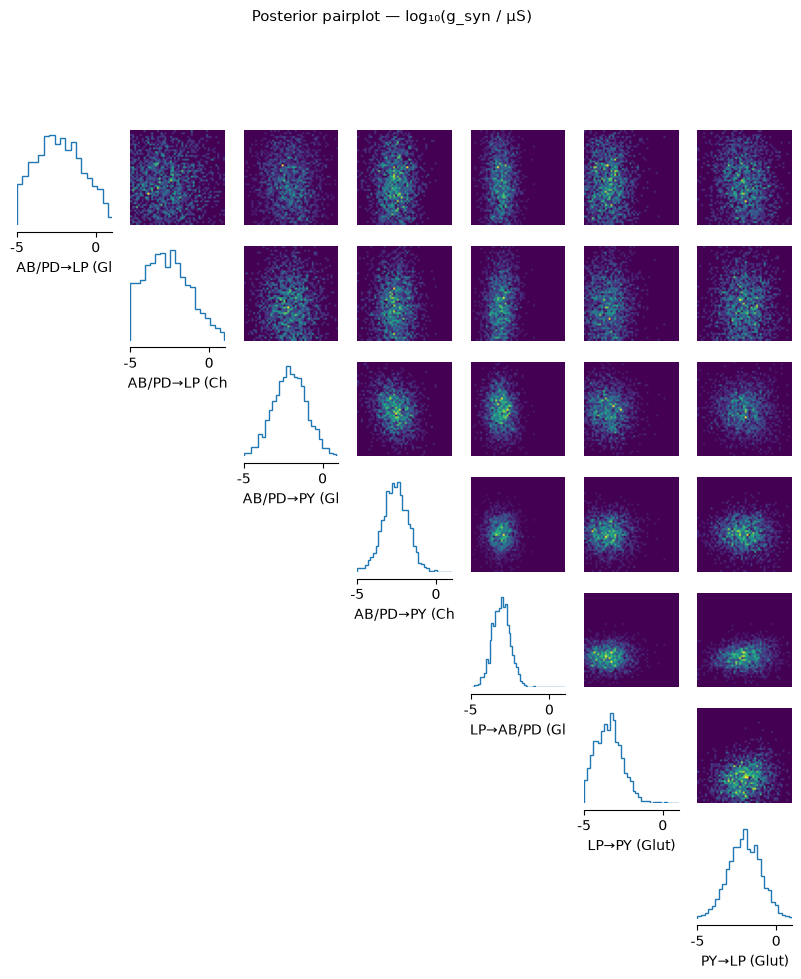

In [ ]:
# Pairplot of log10(g) posterior
try:
    from sbi.analysis import pairplot as sbi_pairplot
    fig, axs_pp = sbi_pairplot(
        posterior_samples,
        labels=[lbl[:12] for lbl in SYNAPSE_LABELS],
        figsize=(10, 10),
        limits=[[-5, 1]] * 7,
    )
    fig.suptitle('Posterior pairplot — log₁₀(g_syn / µS)', fontsize=11, y=1.02)
    plt.show()
except ImportError:
    print('sbi pairplot not available; using seaborn instead.')
    import seaborn as sns
    df_log = pd.DataFrame(ps_np, columns=[lbl[:12] for lbl in SYNAPSE_LABELS])
    g = sns.PairGrid(df_log)
    g.map_upper(sns.scatterplot, s=2, alpha=0.3)
    g.map_lower(sns.kdeplot)
    g.map_diag(sns.histplot, bins=30)
    g.fig.suptitle('Posterior pairplot — log₁₀(g_syn / µS)', y=1.01)
    plt.show()